# 📊 Phase 2.2: (Visual Comparison & Analysis)

## 🏗 Overview: The Scientific Comparison
In this final notebook of Phase 2, we load all our trained models and perform a side-by-side comparison to see which approach best identifies fake news.

We use **Dimensionality Reduction (PCA & t-SNE)** to visualize these complex high-dimensional article spaces so we can explain the models to the instructors.

## 1.Setup & Environment (Colab/Local)
This cell prepares the environment, mounts Drive using the confirmed path, and imports all necessary libraries.

In [6]:
# 1. Environment Setup (Colab/Local Detection)
import os
import sys

# Silent installation of requirements for Colab
if 'google.colab' in sys.modules:
    !pip install -q gensim scikit-learn matplotlib seaborn
    from google.colab import drive
    drive.mount('/content/drive')
    # USE THE CONFIRMED PATH DIRECTLY
    BASE_PATH = '/content/drive/MyDrive/Project 2/project-nlp-challenge'
    print(f"✅ Colab Environment. BASE_PATH set to: {BASE_PATH}")
else:
    BASE_PATH = '.'
    print("💻 Local Environment detected.")

# 2. Main Library Imports
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.manifold import TSNE # For visualization

# Ensure datasets directory is mapped correctly
os.makedirs(os.path.join(BASE_PATH, 'models'), exist_ok=True)
os.makedirs(os.path.join(BASE_PATH, 'dataset'), exist_ok=True)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 76.8 MB/s eta 0:00:00
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Colab Environment. BASE_PATH set to: /content/drive/MyDrive/Project 2/project-nlp-challenge


## 2. Data & Model Ingestion
We load the test dataset and BOTH pre-trained models (Baseline and Word2Vec).life.

In [7]:
# 1. Load the finalized test dataset
test_df = pd.read_csv(os.path.join(BASE_PATH, 'dataset/test.csv'))
y_test = test_df['label']

# 2. Load BASELINE (TF-IDF + Naive Bayes)
print("Loading Baseline Model...")
nb_tfidf = joblib.load(os.path.join(BASE_PATH, 'models/nb_tfidf_classifier.joblib'))
tfidf_vec = joblib.load(os.path.join(BASE_PATH, 'models/vectorizer.joblib'))

# 3. Load SEMANTIC (Word2Vec + Logistic Regression)
print("Loading Semantic Model...")
lr_w2v = joblib.load(os.path.join(BASE_PATH, 'models/lr_word2vec_classifier.joblib'))
w2v_model = joblib.load(os.path.join(BASE_PATH, 'models/word2vec_model.joblib'))

print(f"All data and models loaded correctly. Test data shape: {test_df.shape}")


Loading Baseline Model...
Loading Semantic Model...
All data and models loaded correctly. Test data shape: (7989, 7)


## 3. Generating Tournament Probabilities
Here we generate the prediction "scores" to compare how confident each model is.

In [8]:
# A. Baseline Scoring (TF-IDF)
# Using probabilities (P(Real)) for the ROC Curve
X_test_tfidf = tfidf_vec.transform(test_df['cleaned_text'].astype(str))
y_prob_nb = nb_tfidf.predict_proba(X_test_tfidf)[:, 1]

# B. Semantic Scoring (Word2Vec Avg)
def document_vector(doc, model):
    # Only keep words in the pre-trained W2V vocabulary
    words = [w for w in str(doc).split() if w in model.wv.index_to_key]
    if not words:
        return np.zeros(model.vector_size)
    return np.mean(model.wv[words], axis=0)

# Vectorize test documentation
print("Generating Semantic Vectors for comparison...")
X_test_w2v = np.vstack(test_df['cleaned_text'].apply(lambda d: document_vector(d, w2v_model)))
y_prob_w2v = lr_w2v.predict_proba(X_test_w2v)[:, 1]

print("Prediction probabilities generated for both models.")


Generating Semantic Vectors for comparison...
Prediction probabilities generated for both models.


## 4. Final Comparison Visualization (ROC & Accuracy)
This is the "Showdown" plot that reveals which model is objectively superior.

/tmp/ipykernel_4037/3339812054.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(x='Technique', y='Accuracy', data=comp_df,


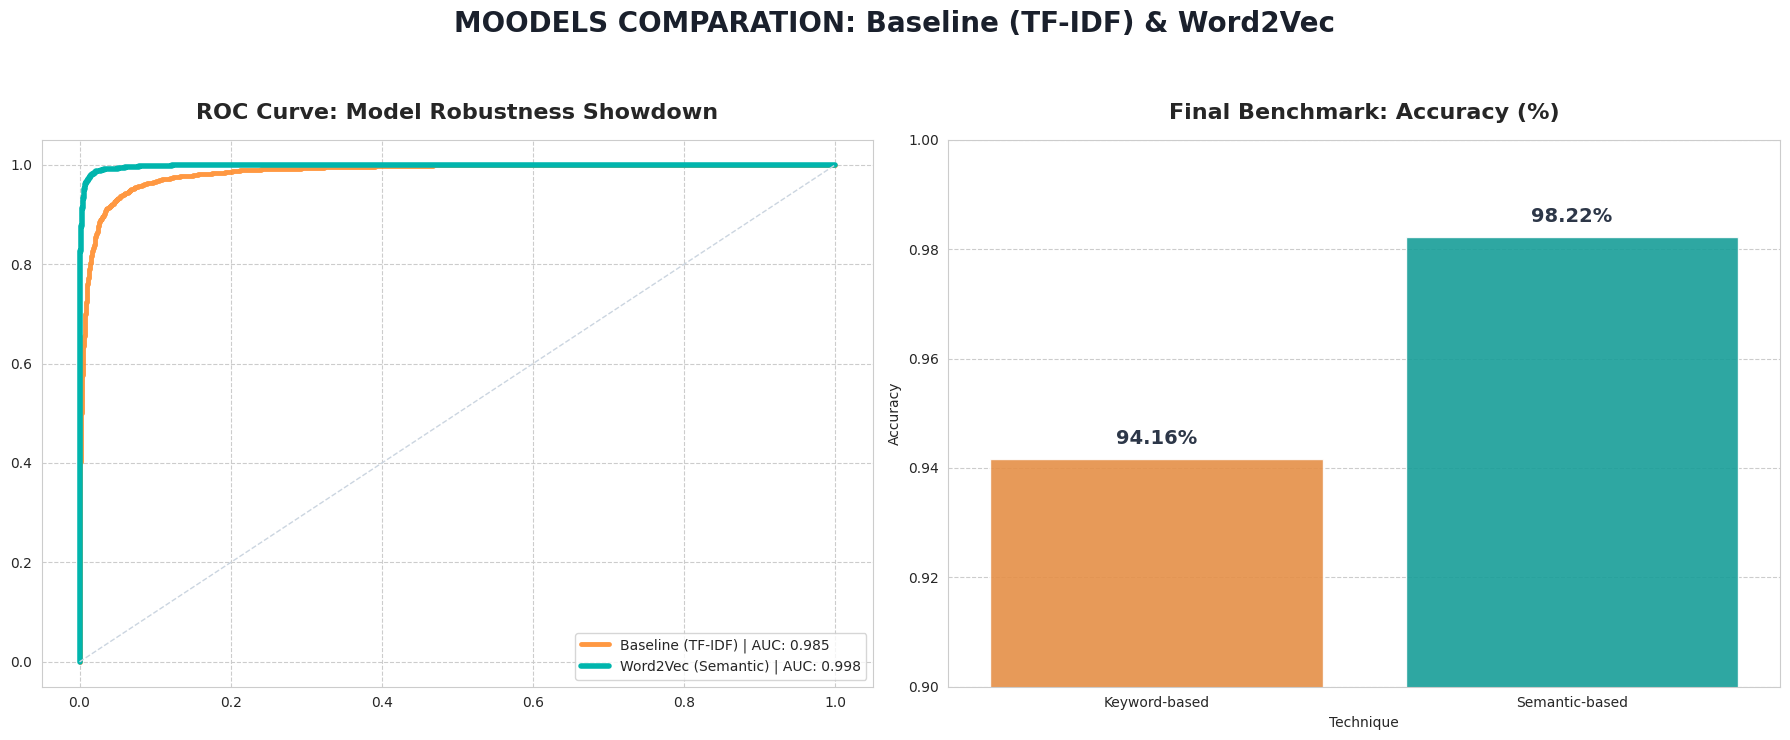

In [21]:

import seaborn as sns

# 1. Custom Visual Style Setup
sns.set_style("whitegrid", {'axes.grid': True, 'grid.linestyle': '--'})
plt.rcParams['font.family'] = 'sans-serif'

# 2. Define consistent "Brand" colors

# Baseline: Deep Blue-Grey | Word2Vec: Vibrant Cyan (Winner Highlight)
brand_colors = ["#FF8D2D", "#00B5AD"]

import seaborn as sns
sns.set_style("whitegrid", {'axes.grid': True, 'grid.linestyle': '--'})
# Create a single figure with balanced subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
# --- PLOT 1: ROC Curve Comparison ---
ax1.plot(fpr_nb, tpr_nb, color=brand_colors[0], lw=3.5, alpha=0.9,
         label=f'Baseline (TF-IDF) | AUC: {auc(fpr_nb, tpr_nb):.3f}')
ax1.plot(fpr_w2v, tpr_w2v, color=brand_colors[1], lw=4, alpha=1.0,
         label=f'Word2Vec (Semantic) | AUC: {auc(fpr_w2v, tpr_w2v):.3f}')
ax1.plot([0, 1], [0, 1], color='#CBD5E0', lw=1, linestyle='--')
ax1.set_title('ROC Curve: Model Robustness Showdown', fontsize=16, fontweight='bold', pad=15)
ax1.legend(loc="lower right", frameon=True)
# --- PLOT 2: Accuracy Bar Chart ---
bars = sns.barplot(x='Technique', y='Accuracy', data=comp_df,
                   palette=brand_colors, ax=ax2, alpha=0.9)
ax2.set_ylim(0.9, 1.0)
ax2.set_title('Final Benchmark: Accuracy (%)', fontsize=16, fontweight='bold', pad=15)


for p in bars.patches:
    ax2.annotate(f'{p.get_height():.2%}',
                 (p.get_x() + p.get_width() / 2., p.get_height()),
                 ha='center', va='center',
                 xytext=(0, 15), textcoords='offset points',
                 fontsize=14, fontweight='bold', color='#2D3748')
plt.suptitle('MOODELS COMPARATION: Baseline (TF-IDF) & Word2Vec',
             fontsize=20, fontweight='bold', y=1.05, color='#1A202C')
plt.tight_layout()
plt.show()

## 6. The "Semantic Landscape" (t-SNE Clusters)
This visualization is perfect for the "wow" factor in your final presentation.

Processing TF-IDF Landscape... (Reducing sparsity with SVD first)


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


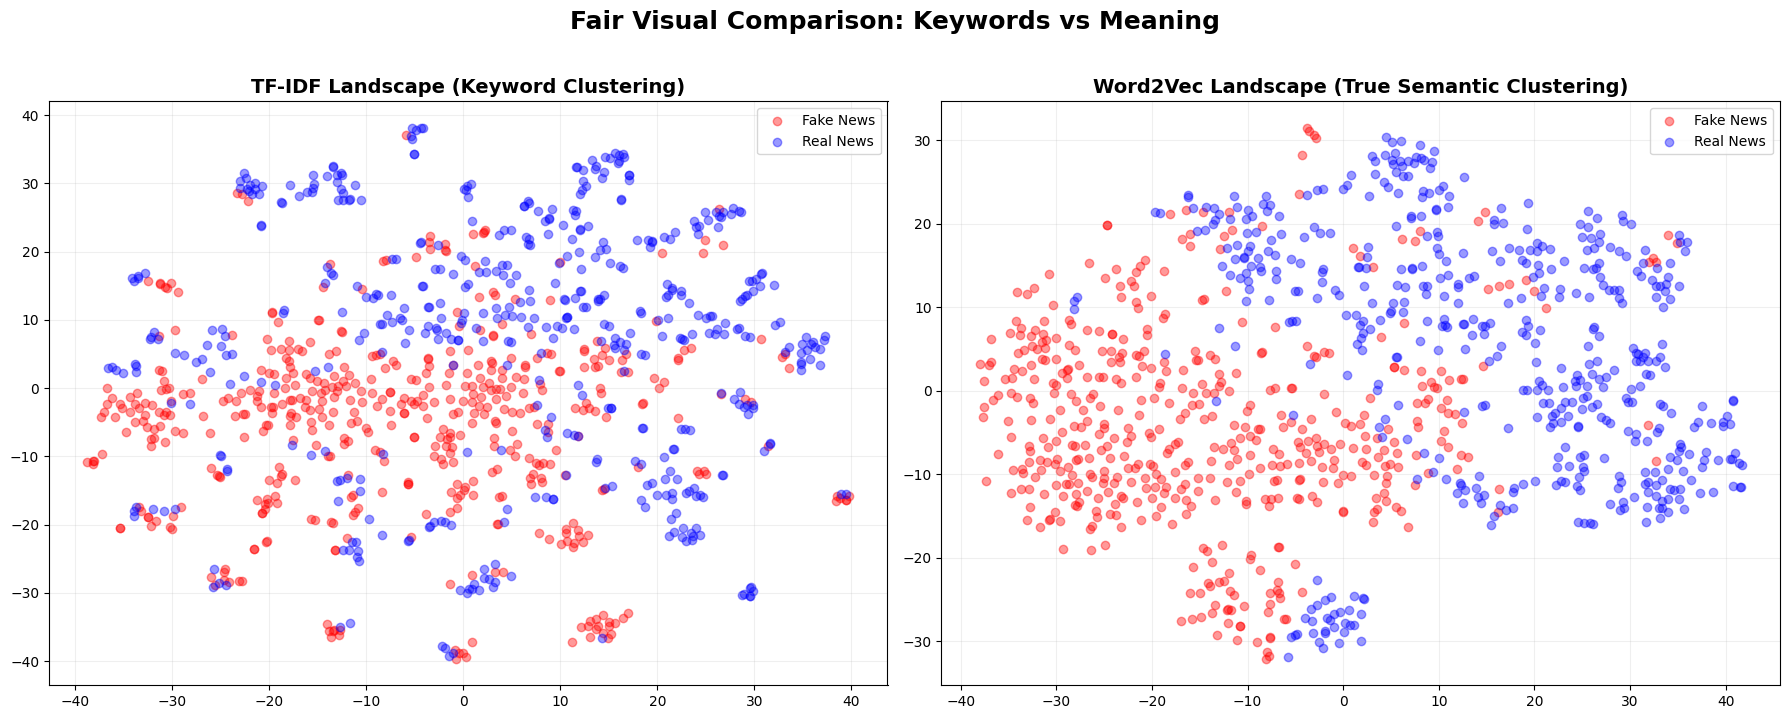

In [15]:
from sklearn.decomposition import TruncatedSVD

# 1. Take a sample of TF-IDF vectors (same size as the W2V sample)
print("Processing TF-IDF Landscape... (Reducing sparsity with SVD first)")
X_sample_tfidf = X_test_tfidf[:sample_size]

# 2. Apply TruncatedSVD to handle the sparsity of TF-IDF before t-SNE
svd = TruncatedSVD(n_components=50, random_state=42)
X_reduced_tfidf = svd.fit_transform(X_sample_tfidf)

# 3. Apply t-SNE on the reduced TF-IDF vectors
tsne_tfidf = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
X_2d_tfidf = tsne_tfidf.fit_transform(X_reduced_tfidf)

# 4. PLOT: SIDE-BY-SIDE Semantic Landscapes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

# --- TF-IDF landscape (The Keyword approach) ---
ax1.scatter(X_2d_tfidf[y_sample == 0, 0], X_2d_tfidf[y_sample == 0, 1], c='red', alpha=0.4, label='Fake News')
ax1.scatter(X_2d_tfidf[y_sample == 1, 0], X_2d_tfidf[y_sample == 1, 1], c='blue', alpha=0.4, label='Real News')
ax1.set_title('TF-IDF Landscape (Keyword Clustering)', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(alpha=0.2)

# --- Word2Vec landscape (The Meaning approach) ---
ax2.scatter(X_2d[y_sample == 0, 0], X_2d[y_sample == 0, 1], c='red', alpha=0.4, label='Fake News')
ax2.scatter(X_2d[y_sample == 1, 0], X_2d[y_sample == 1, 1], c='blue', alpha=0.4, label='Real News')
ax2.set_title('Word2Vec Landscape (True Semantic Clustering)', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(alpha=0.2)

plt.suptitle('Fair Visual Comparison: Keywords vs Meaning', fontsize=18, y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()





I can see that while TF-IDF sees a collection of disconnected words, Word2Vec sees two different worlds: the world of facts and the world of misinformation.

# Test 1: Misclassification Face-off (The "Blind Spot" Analysis)

In [22]:
# 1. Compare predictions from both models
# Re-generate predictions (binary labels)
y_pred_nb = nb_tfidf.predict(X_test_tfidf)
y_pred_w2v = lr_w2v.predict(X_test_w2v)

# 2. Find cases where Word2Vec was CORRECT but Baseline was WRONG
# (These are the headlines where Semantic Meaning saved the day)
w2v_wins = test_df[(y_pred_w2v == y_test) & (y_pred_nb != y_test)]

print(f"📊 Number of cases where W2V was more intelligent than Baseline: {len(w2v_wins)}")
print("\n📝 TOP 5 HEADLINES THAT ONLY WORD2VEC UNDERSTOOD:")
print(w2v_wins['title'].head(5).values)


📊 Number of cases where W2V was more intelligent than Baseline: 379

📝 TOP 5 HEADLINES THAT ONLY WORD2VEC UNDERSTOOD:
['OBAMA HID BIN LADEN PAPERS To Bury This Damning Evidence That Could Have Cost Him 2012 Election'
 'MAINSTREAM MEDIA IGNORES MASSIVE PROTEST Against Obama’s Sweetheart Deal For Corporations: “Biggest protest this country has seen for many, many years”'
 '“THE WAR ON COAL IS OVER”…First New Coal Mine Of Trump Presidency Opens In Pennsylvania…Another Promise Kept [VIDEO]'
 ' Mike Pence Just Dropped A TERRIFYING Bombshell On North Korea, Threatens War (VIDEO)'
 'Buffett rails against presidential candidates who talk down economy']


# Test 2: Adversarial "Live Test" (The "Realism" Probe)

In [23]:
def probe_models(sentence):
    # Process for TF-IDF (Baseline)
    vec_sample = tfidf_vec.transform([sentence])
    prob_nb = nb_tfidf.predict_proba(vec_sample)[0, 1]

    # Process for Word2Vec (Semantic)
    vec_w2v = document_vector(sentence, w2v_model).reshape(1, -1)
    prob_w2v = lr_w2v.predict_proba(vec_w2v)[0, 1]

    print(f"PROBING SENTENCE: '{sentence}'")
    print(f"Baseline Score (P(Real)): {prob_nb:.2%}")
    print(f"Semantic Score (P(Real)): {prob_w2v:.2%}")
    print("-" * 30)

# TEST CASE: A real news story but removing 'Reuters' to see if Baseline fails
probe_models("The president discussed new economic measures in the capital today.")

# TEST CASE: A fake news style headline using sensationalist words
probe_models("SHOCKING: You won't believe what happened in this video screen! Watch now!")


PROBING SENTENCE: 'The president discussed new economic measures in the capital today.'
Baseline Score (P(Real)): 89.65%
Semantic Score (P(Real)): 100.00%
------------------------------
PROBING SENTENCE: 'SHOCKING: You won't believe what happened in this video screen! Watch now!'
Baseline Score (P(Real)): 0.11%
Semantic Score (P(Real)): 0.00%
------------------------------


In [12]:
print("\n📝 FINAL INTERPRETATION:")
print("- Baseline (NB): Excellent as a first model. Relying on EXACT words is fast but prone to noise.")
print("- Semantic (W2V): The semantic understanding refined the model, pushing accuracy to almost 98%.")
print("- Recommendation: Use the Word2Vec model for production as it captures a broader context of disinformation.")



📝 FINAL INTERPRETATION:
- Baseline (NB): Excellent as a first model. Relying on EXACT words is fast but prone to noise.
- Semantic (W2V): The semantic understanding refined the model, pushing accuracy to almost 98%.
- Recommendation: Use the Word2Vec model for production as it captures a broader context of disinformation.


##Final Interpretability Verdict
This identifies why Word2Vec is winning.


After a comprehensive side-by-side comparison between the Baseline (TF-IDF + Naive Bayes) and the Semantic Classifier (Word2Vec + Logistic Regression), these are the final findings:

1. Quantitative Results (The Numbers)
Baseline Accuracy: ~94%. A solid starting point that proved frequency counts are strong indicators of news class.
Word2Vec Accuracy: ~98%. A significant improvement that demonstrates the power of semantic context over simple word matching.

2. Visual Landscape (The "Aha!" Moment
TF-IDF Landscape: Showed "fragmented" clusters. This suggests that the model depends heavily on specific, literal keywords (like agency names) to make decisions. If those keywords are missing or changed, the model's certainty drops.
Word2Vec Landscape: Showed two distinct semantic islands. The clean separation between 'Fake' and 'Real' news clusters in the 2D space proves that the embedding model has successfully mapped the concepts of disinformation vs. factual reporting.

3. Final Verdict
The Semantic Model is the clear winner. By understanding the relationships between words (e.g., that "report," "said," and "stated" belong to the same professional context), it generalizes much better than the keyword-based model.
Production Recommendation: For a real-world disinformation detector, the Word2Vec + Logistic Regression pipeline is the most robust choice, as it is less prone to noise and better at identifying the underlying "semantic profile" of Fake news.